In [30]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


In [31]:
import pandas
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [32]:
train = pd.read_csv("/kaggle/input/playground-series-s5e10/train.csv")
test =  pd.read_csv("/kaggle/input/playground-series-s5e10/test.csv")

In [33]:
target_column = 'accident_risk'

In [34]:
time_of_day_mapping = {'morning' :1, 'afternoon' : 2, 'evening' : 3}
lighting_mapping = {'daylight' : 1, 'dim' : 2, 'night': 3}

train['time_of_day_encoded'] = train['time_of_day'].map(time_of_day_mapping)
train['lighting_encoded'] = train['lighting'].map(lighting_mapping)

nominal_features = ['road_type', 'weather']

# Generate one-hot encoded columns (creates a new DataFrame of dummies)
train_dummies = pd.get_dummies(train[nominal_features], columns=nominal_features, drop_first=True)

# Concatenate the new dummy columns back to the original DataFrame for further analysis
train = pd.concat([train, train_dummies], axis=1)



#Feature Interaction and Combination 

# Speed Limit per Lane
# Measures how fast the traffic is allowed to move relative to the road's capacity/width
train['speed_limit_per_lane'] = train['speed_limit'] / train['num_lanes']

#Curvature-Speed Interaction
# Captures the increased risk of a sharp curve (high curvature) at a high speed.
train['curvature_speed_interaction'] = train['curvature'] * train['speed_limit']

#Time of Day and Lighting Interaction (Specific High-Risk Combo)
# lighting_encoded: 1=daylight, 2=dim, 3=night
# time_of_day_encoded: 1=morning, 2=afternoon, 3=evening
train['high_risk_light_time'] = (
    (train['lighting_encoded'] >= 2) & # Dim or Night
    (train['time_of_day_encoded'] == 3) # Evening
).astype(int)

# --- 2. Encoding Enhancements ---

#Cyclical Encoding for 'time_of_day'
# Replaces the ordinal (1, 2, 3) with sine/cosine to capture the cyclical nature.
n_times = 3
train['time_of_day_sin'] = np.sin(2 * np.pi * (train['time_of_day_encoded'] - 1) / n_times)
train['time_of_day_cos'] = np.cos(2 * np.pi * (train['time_of_day_encoded'] - 1) / n_times)

# Target Encoding for 'road_type' and 'weather'

road_type_risk_map = train.groupby('road_type')['accident_risk'].mean()
train['road_type_target_encoded'] = train['road_type'].map(road_type_risk_map)

weather_risk_map = train.groupby('weather')['accident_risk'].mean()
train['weather_target_encoded'] = train['weather'].map(weather_risk_map)


In [35]:
train_data_encoded = train.drop(['lighting','time_of_day', 'weather', 'road_type', 'lighting', 'time_of_day' ], axis = 'columns')

<function matplotlib.pyplot.show(close=None, block=None)>

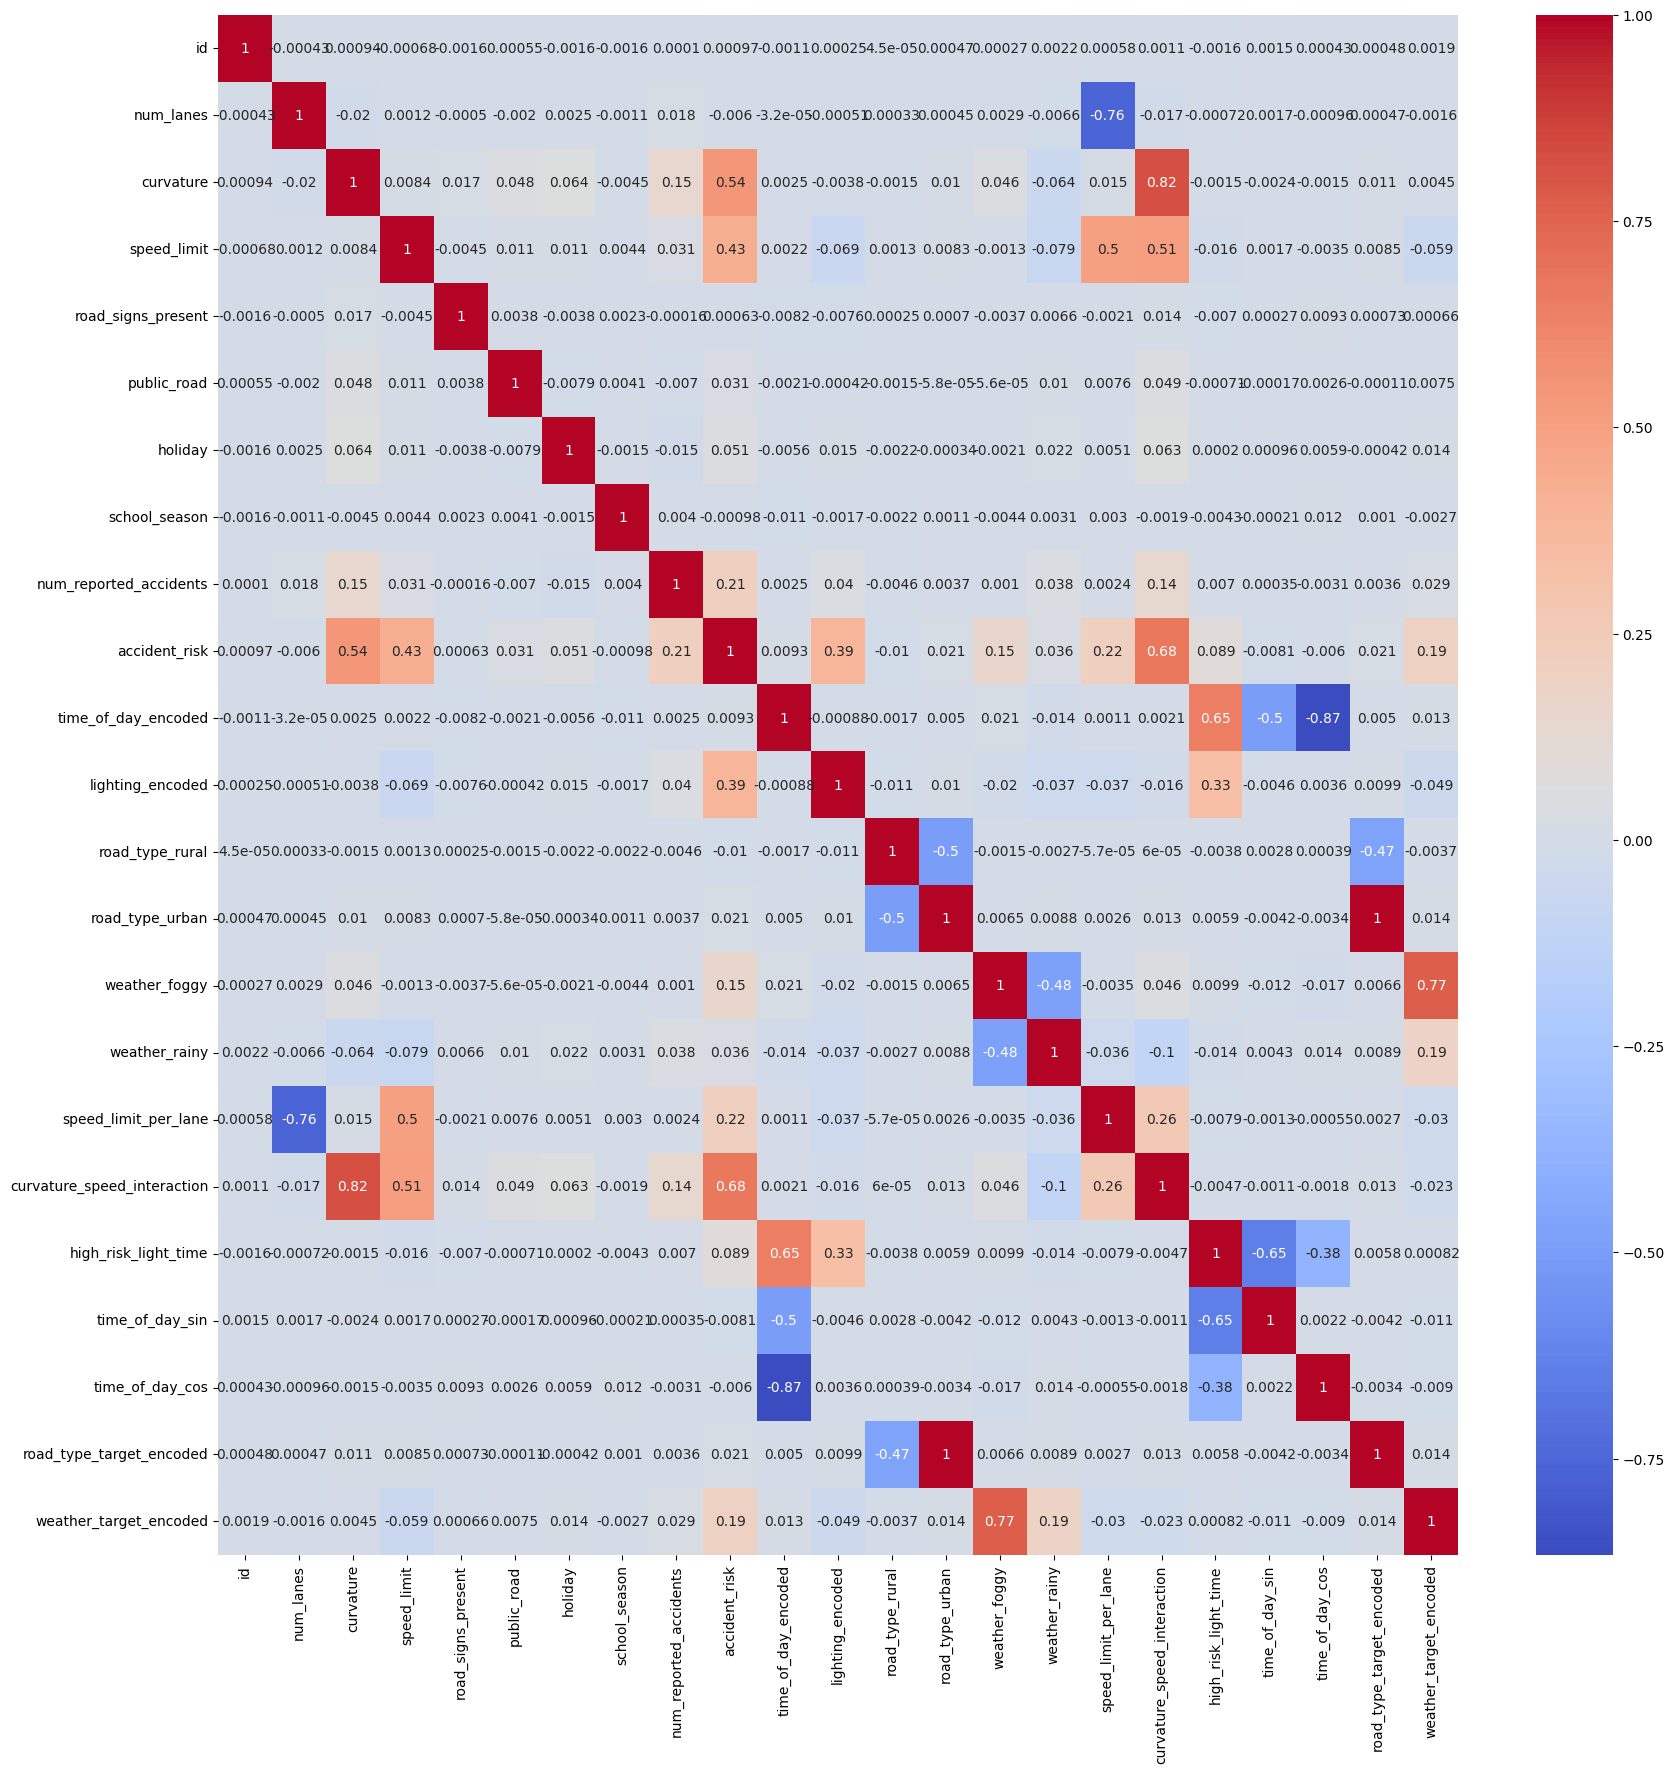

In [36]:
corr_matrix=train_data_encoded.corr()

plt.figure(figsize=(20,20))
sns.heatmap(corr_matrix, annot = True, cmap='coolwarm')
plt.show

In [37]:
target_column = 'accident_risk'
final_train_data = train_data_encoded.drop(columns=[
    'id', target_column 
])

In [38]:
#  Ordinal Encoding für das Test Set
test['time_of_day_encoded'] = test['time_of_day'].map(time_of_day_mapping)
test['lighting_encoded'] = test['lighting'].map(lighting_mapping)

#One-Hot Encoding für das Test Set
nominal_features_test = ['road_type', 'weather']
test_dummies = pd.get_dummies(test[nominal_features_test], columns=nominal_features_test, drop_first=True)
test = pd.concat([test, test_dummies], axis=1)

#  Feature Interaction and Combination

#Speed Limit per Lane
test['speed_limit_per_lane'] = test['speed_limit'] / test['num_lanes']

# Curvature-Speed Interaction
test['curvature_speed_interaction'] = test['curvature'] * test['speed_limit']

# Time of Day and Lighting Interaction (Specific High-Risk Combo)
test['high_risk_light_time'] = (
    (test['lighting_encoded'] >= 2) &
    (test['time_of_day_encoded'] == 3)
).astype(int)

# Encoding Enhancements

# Cyclical Encoding for 'time_of_day
n_times = 3
test['time_of_day_sin'] = np.sin(2 * np.pi * (test['time_of_day_encoded'] - 1) / n_times)
test['time_of_day_cos'] = np.cos(2 * np.pi * (test['time_of_day_encoded'] - 1) / n_times)

# Encoding for road_type and weather
test['road_type_target_encoded'] = test['road_type'].map(road_type_risk_map)
test['weather_target_encoded'] = test['weather'].map(weather_risk_map)




# Final Cleanup 

columns_to_drop = [
    'lighting', 'time_of_day', 'weather', 'road_type']
test_encoded = test.drop(columns=columns_to_drop, errors='ignore')



In [39]:
# Prepare Final Training and Test Sets ---
#

#  Define target and feature columns from the processed training data
target_column = 'accident_risk'
id_column = 'id'

# Drop columns that won't be used for training

features_to_drop_from_train = [target_column, id_column]
X_full = train_data_encoded.drop(columns=features_to_drop_from_train)
y_full = train_data_encoded[target_column]

# Align columns: This is a CRITICAL step!
# The test set might be missing a category (e.g., 'weather_foggy'), which means
# get_dummies would create fewer columns. This aligns them, filling any missing
# columns in the test set with 0.
train_cols = X_full.columns
test_cols = test_encoded.columns

# We select only the columns from the test set that are also in the training set
# and in the same order.
X_test = test_encoded[train_cols]



In [40]:
# Train the Final Model 


print("Training the final model on all available training data...")
best_params = {
    'n_estimators': 300,
    'min_samples_leaf': 4,
    'max_features': 'sqrt',
    'max_depth': 30
}

final_model = RandomForestRegressor(
    **best_params,  # Unpacks the dictionary into keyword arguments
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_full, y_full)
print("Final model training complete!")

Training the final model on all available training data...
Final model training complete!


In [41]:
#  Step 4: Make Predictions on the Test Set 
print("Making predictions on the test data...")
test_predictions = final_model.predict(X_test)

# Clipping: It's good practice to ensure predictions are within a valid range (e.g., 0 to 1).

clipped_test_predictions = np.clip(test_predictions, 0, 1)

Making predictions on the test data...


In [42]:
#  Create the Submission File 


print("Creating the submission file...")
submission = pd.DataFrame({
    'id': test[id_column],  # Use the ID from the original test set
    'accident_risk': clipped_test_predictions
})

# Validation checks 
assert submission.shape[0] == test.shape[0]
assert submission['accident_risk'].isna().sum() == 0
assert (submission['accident_risk'] >= 0).all()
assert (submission['accident_risk'] <= 1).all()

# Save file
submission.to_csv('submission.csv', index=False)

print("\n" + "=" * 60)
print("Submission Created Successfully: submission.csv")
print("=" * 60)
print(f"Shape: {submission.shape}")
print(f"\nPrediction Statistics:")
print(f"  Mean: {submission['accident_risk'].mean():.4f}")
print(f"  Std: {submission['accident_risk'].std():.4f}")
print(f"  Min: {submission['accident_risk'].min():.4f}")
print(f"  Max: {submission['accident_risk'].max():.4f}")
print(f"\nFirst 10 predictions:")
print(submission.head(10))

Creating the submission file...

Submission Created Successfully: submission.csv
Shape: (172585, 2)

Prediction Statistics:
  Mean: 0.3516
  Std: 0.1548
  Min: 0.0321
  Max: 0.8676

First 10 predictions:
       id  accident_risk
0  517754       0.308638
1  517755       0.124994
2  517756       0.175410
3  517757       0.326044
4  517758       0.400976
5  517759       0.447402
6  517760       0.276473
7  517761       0.195901
8  517762       0.379366
9  517763       0.315623
